# GHSL — population quickstart

Download GHS-POP 2020 at 100 m over a small Lisbon AOI and map the residential population grid. The Mollweide source tile is reprojected to WGS84 and cropped to the bbox by `pyramids`.

In [1]:
import tempfile

from earthlens import EarthLens

out = tempfile.mkdtemp()
paths = EarthLens(
    data_source='ghsl',
    variables=['GHS_POP'],
    start='2020-01-01',
    end='2020-12-31',
    aoi=[-9.20, 38.68, -9.10, 38.78],
    path=out,
).download(progress_bar=False)
paths

2026-05-28 22:47:14 | INFO | pyramids.base.config | Logging is configured.


[WindowsPath('C:/Users/main/AppData/Local/Temp/claude/tmpkzubcl59/GHS_POP_E2020_100m_epsg4326.tif')]

Read the written GeoTIFF and plot it (people per 100 m cell):

epsg 4326 | shape (94, 94)


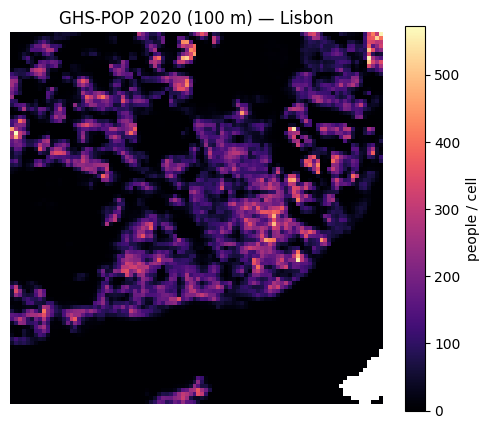

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

ds = Dataset.read_file(str(paths[0]))
arr = np.asarray(ds.read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
arr = np.where(arr < 0, np.nan, arr)
print('epsg', ds.epsg, '| shape', arr.shape)
plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='magma')
plt.colorbar(label='people / cell')
plt.title('GHS-POP 2020 (100 m) — Lisbon')
plt.axis('off')
plt.show()

A quick headline number — total residents in the AOI:

In [3]:
print(f'total population in AOI: {np.nansum(arr):,.0f}')

total population in AOI: 479,570
